In [2]:
from pathlib import Path
import openpyxl
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
project_dir = Path.cwd().parent.resolve()
print(f"Project directory: {project_dir}")

data_IMAGE_projections = f"{project_dir}/data/input/models/IMAGE_ScenarioMIP/scenarios"
print(f"Data directory: {data_IMAGE_projections}")

Project directory: K:\PythonWork\downscaling\Kaya_downscaling
Data directory: K:\PythonWork\downscaling\Kaya_downscaling/data/input/models/IMAGE_ScenarioMIP/scenarios


In [4]:
Urban_CO2 = ["Emissions|CO2", "Emissions|CO2|AFOLU",
             "Emissions|CO2|Energy|Demand|Bunkers|International Aviation", "Emissions|CO2|Energy|Demand|Bunkers|International Shipping",
             "Emissions|CO2|Energy|Demand|Transportation|Domestic Aviation"]


In [5]:
Medium_SSP2_path = Path(data_IMAGE_projections) / "IMAGE 3.4_Medium - SSP2.xlsx"
df_Medium_SSP2 = pd.read_excel(Medium_SSP2_path, sheet_name="data")
Low_SSP2_path = Path(data_IMAGE_projections) / "IMAGE 3.4_Low - SSP2.xlsx"
df_Low_SSP2 = pd.read_excel(Low_SSP2_path, sheet_name="data")
df_IMAGE = pd.concat([df_Medium_SSP2, df_Low_SSP2], axis=0)

In [6]:
df_IMAGE_CO2 = df_IMAGE[df_IMAGE["Variable"].isin(Urban_CO2)]
df_IMAGE_CO2 = df_IMAGE_CO2.melt(id_vars=["Model", "Scenario", "Region", "Variable", "Unit"], var_name="Year", value_name="Value")
mask_aviation = (df_IMAGE_CO2["Variable"]=="Emissions|CO2|Energy|Demand|Bunkers|International Aviation") & (df_IMAGE_CO2["Region"]!="World")
df_IMAGE_CO2.loc[mask_aviation, "Value"] = 0.0
mask_shipping = (df_IMAGE_CO2["Variable"]=="Emissions|CO2|Energy|Demand|Bunkers|International Shipping") & (df_IMAGE_CO2["Region"]!="World")
df_IMAGE_CO2.loc[mask_shipping, "Value"] = 0.0
df_IMAGE_CO2 = df_IMAGE_CO2.drop(columns=["Model", "Unit"])
df_IMAGE_CO2 = df_IMAGE_CO2.pivot(index=["Scenario", "Region", "Year"], columns="Variable", values="Value").reset_index()
mask_aviation = (df_IMAGE_CO2["Emissions|CO2|Energy|Demand|Bunkers|International Aviation"].isna())
df_IMAGE_CO2.loc[mask_aviation, "Emissions|CO2|Energy|Demand|Bunkers|International Aviation"] = 0.0
mask_shipping = (df_IMAGE_CO2["Emissions|CO2|Energy|Demand|Bunkers|International Shipping"].isna())
df_IMAGE_CO2.loc[mask_shipping, "Emissions|CO2|Energy|Demand|Bunkers|International Shipping"] = 0.0
df_IMAGE_CO2["Emissions_CO2_Excl_shipping_aviation_AFOLU"] = (df_IMAGE_CO2["Emissions|CO2"] -
                                                          df_IMAGE_CO2.get("Emissions|CO2|Energy|Demand|Bunkers|International Aviation", 0) -
                                                          df_IMAGE_CO2.get("Emissions|CO2|Energy|Demand|Bunkers|International Shipping", 0) -
                                                          df_IMAGE_CO2["Emissions|CO2|Energy|Demand|Transportation|Domestic Aviation"] -
                                                          df_IMAGE_CO2["Emissions|CO2|AFOLU"])
df_IMAGE_CO2 = df_IMAGE_CO2.melt(id_vars=["Scenario", "Region", "Year"], var_name="Variable", value_name="Value")
df_IMAGE_CO2[df_IMAGE_CO2["Variable"]=="Emissions_CO2_Excl_shipping_aviation_AFOLU"]

,Scenario,Region,Year,Variable,Value
1320,Low - SSP2,Africa (R10),2020,Emissions_CO2_Excl_shipping_aviation_AFOLU,1940.766010
1321,Low - SSP2,Africa (R10),2025,Emissions_CO2_Excl_shipping_aviation_AFOLU,2213.973736
1322,Low - SSP2,Africa (R10),2030,Emissions_CO2_Excl_shipping_aviation_AFOLU,2358.443003
1323,Low - SSP2,Africa (R10),2035,Emissions_CO2_Excl_shipping_aviation_AFOLU,2466.936954
1324,Low - SSP2,Africa (R10),2040,Emissions_CO2_Excl_shipping_aviation_AFOLU,2434.010491
...,...,...,...,...,...
1579,Medium - SSP2,World,2060,Emissions_CO2_Excl_shipping_aviation_AFOLU,29257.317816
1580,Medium - SSP2,World,2070,Emissions_CO2_Excl_shipping_aviation_AFOLU,28421.215532
1581,Medium - SSP2,World,2080,Emissions_CO2_Excl_shipping_aviation_AFOLU,28102.780137
1582,Medium - SSP2,World,2090,Emissions_CO2_Excl_shipping_aviation_AFOLU,27795.790082


In [41]:
mask = (df_IMAGE_CO2["Variable"]=="Emissions_CO2_Excl_shipping_aviation_AFOLU")
df_IMAGE_CO2_total = df_IMAGE_CO2[mask]
df_IMAGE_CO2_total["Variable"] = "Net Emissions_CO2_Excl_shipping_aviation_AFOLU"

# determine gross emissions
Gross_net_CO2 = "Gross Emissions|CO2|Energy|Supply","Gross Emissions|CO2|Energy|Demand", "Emissions|CO2|Energy|Supply", "Emissions|CO2|Energy|Demand"
df_IMAGE_gross_CO2 = df_IMAGE[df_IMAGE["Variable"].isin(Gross_net_CO2)]
df_IMAGE_gross_CO2 = df_IMAGE_gross_CO2.melt(id_vars=["Model", "Scenario", "Region", "Variable", "Unit"], var_name="Year", value_name="Value")
df_IMAGE_gross_CO2 = df_IMAGE_gross_CO2.drop(columns=["Model", "Unit"])
df_IMAGE_gross_CO2 = df_IMAGE_gross_CO2.pivot(index=["Scenario", "Region", "Year"], columns="Variable", values="Value").reset_index()
df_IMAGE_gross_CO2["gross_net_CO2"] = (df_IMAGE_gross_CO2["Gross Emissions|CO2|Energy|Supply"] + df_IMAGE_gross_CO2["Gross Emissions|CO2|Energy|Demand"]) - (df_IMAGE_gross_CO2["Emissions|CO2|Energy|Supply"] + df_IMAGE_gross_CO2["Emissions|CO2|Energy|Demand"])
df_IMAGE_gross_CO2 = df_IMAGE_gross_CO2.melt(id_vars=["Scenario", "Region", "Year"], var_name="Variable", value_name="Value")
df_IMAGE_gross_CO2 = df_IMAGE_gross_CO2[df_IMAGE_gross_CO2["Variable"]=="gross_net_CO2"]
df_IMAGE_gross_CO2 = pd.concat([df_IMAGE_CO2_total, df_IMAGE_gross_CO2], axis=0)
df_IMAGE_gross_CO2 = df_IMAGE_gross_CO2.pivot(index=["Scenario", "Region", "Year"], columns="Variable", values="Value").reset_index()
df_IMAGE_gross_CO2["Gross Emissions_CO2_Excl_shipping_aviation_AFOLU"] = df_IMAGE_gross_CO2["Net Emissions_CO2_Excl_shipping_aviation_AFOLU"] + df_IMAGE_gross_CO2["gross_net_CO2"]
df_IMAGE_gross_CO2 = df_IMAGE_gross_CO2.melt(id_vars=["Scenario", "Region", "Year"], var_name="Variable", value_name="Value")
df_IMAGE_gross_CO2 = df_IMAGE_gross_CO2[df_IMAGE_gross_CO2["Variable"]=="Gross Emissions_CO2_Excl_shipping_aviation_AFOLU"]

# concat
df_IMAGE_CO2_total = pd.concat([df_IMAGE_CO2_total, df_IMAGE_gross_CO2], axis=0)
# print
df_IMAGE_CO2_total[(df_IMAGE_CO2_total["Year"]==2050) & (df_IMAGE_CO2_total["Region"]=="Africa (R10)")]
#df_IMAGE_gross_CO2

C:\Users\roelfsemam\AppData\Local\Temp\2\ipykernel_8828\1537214716.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IMAGE_CO2_total["Variable"] = "Net Emissions_CO2_Excl_shipping_aviation_AFOLU"


,Scenario,Region,Year,Variable,Value
1326,Low - SSP2,Africa (R10),2050,Net Emissions_CO2_Excl_shipping_aviation_AFOLU,1442.265857
1458,Medium - SSP2,Africa (R10),2050,Net Emissions_CO2_Excl_shipping_aviation_AFOLU,3840.769900
534,Low - SSP2,Africa (R10),2050,Gross Emissions_CO2_Excl_shipping_aviation_AFOLU,1732.680553
666,Medium - SSP2,Africa (R10),2050,Gross Emissions_CO2_Excl_shipping_aviation_AFOLU,3839.677465


k:\PythonWork\downscaling\Kaya_downscaling\.pixi\envs\default\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  func(*args, **kwargs)
k:\PythonWork\downscaling\Kaya_downscaling\.pixi\envs\default\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


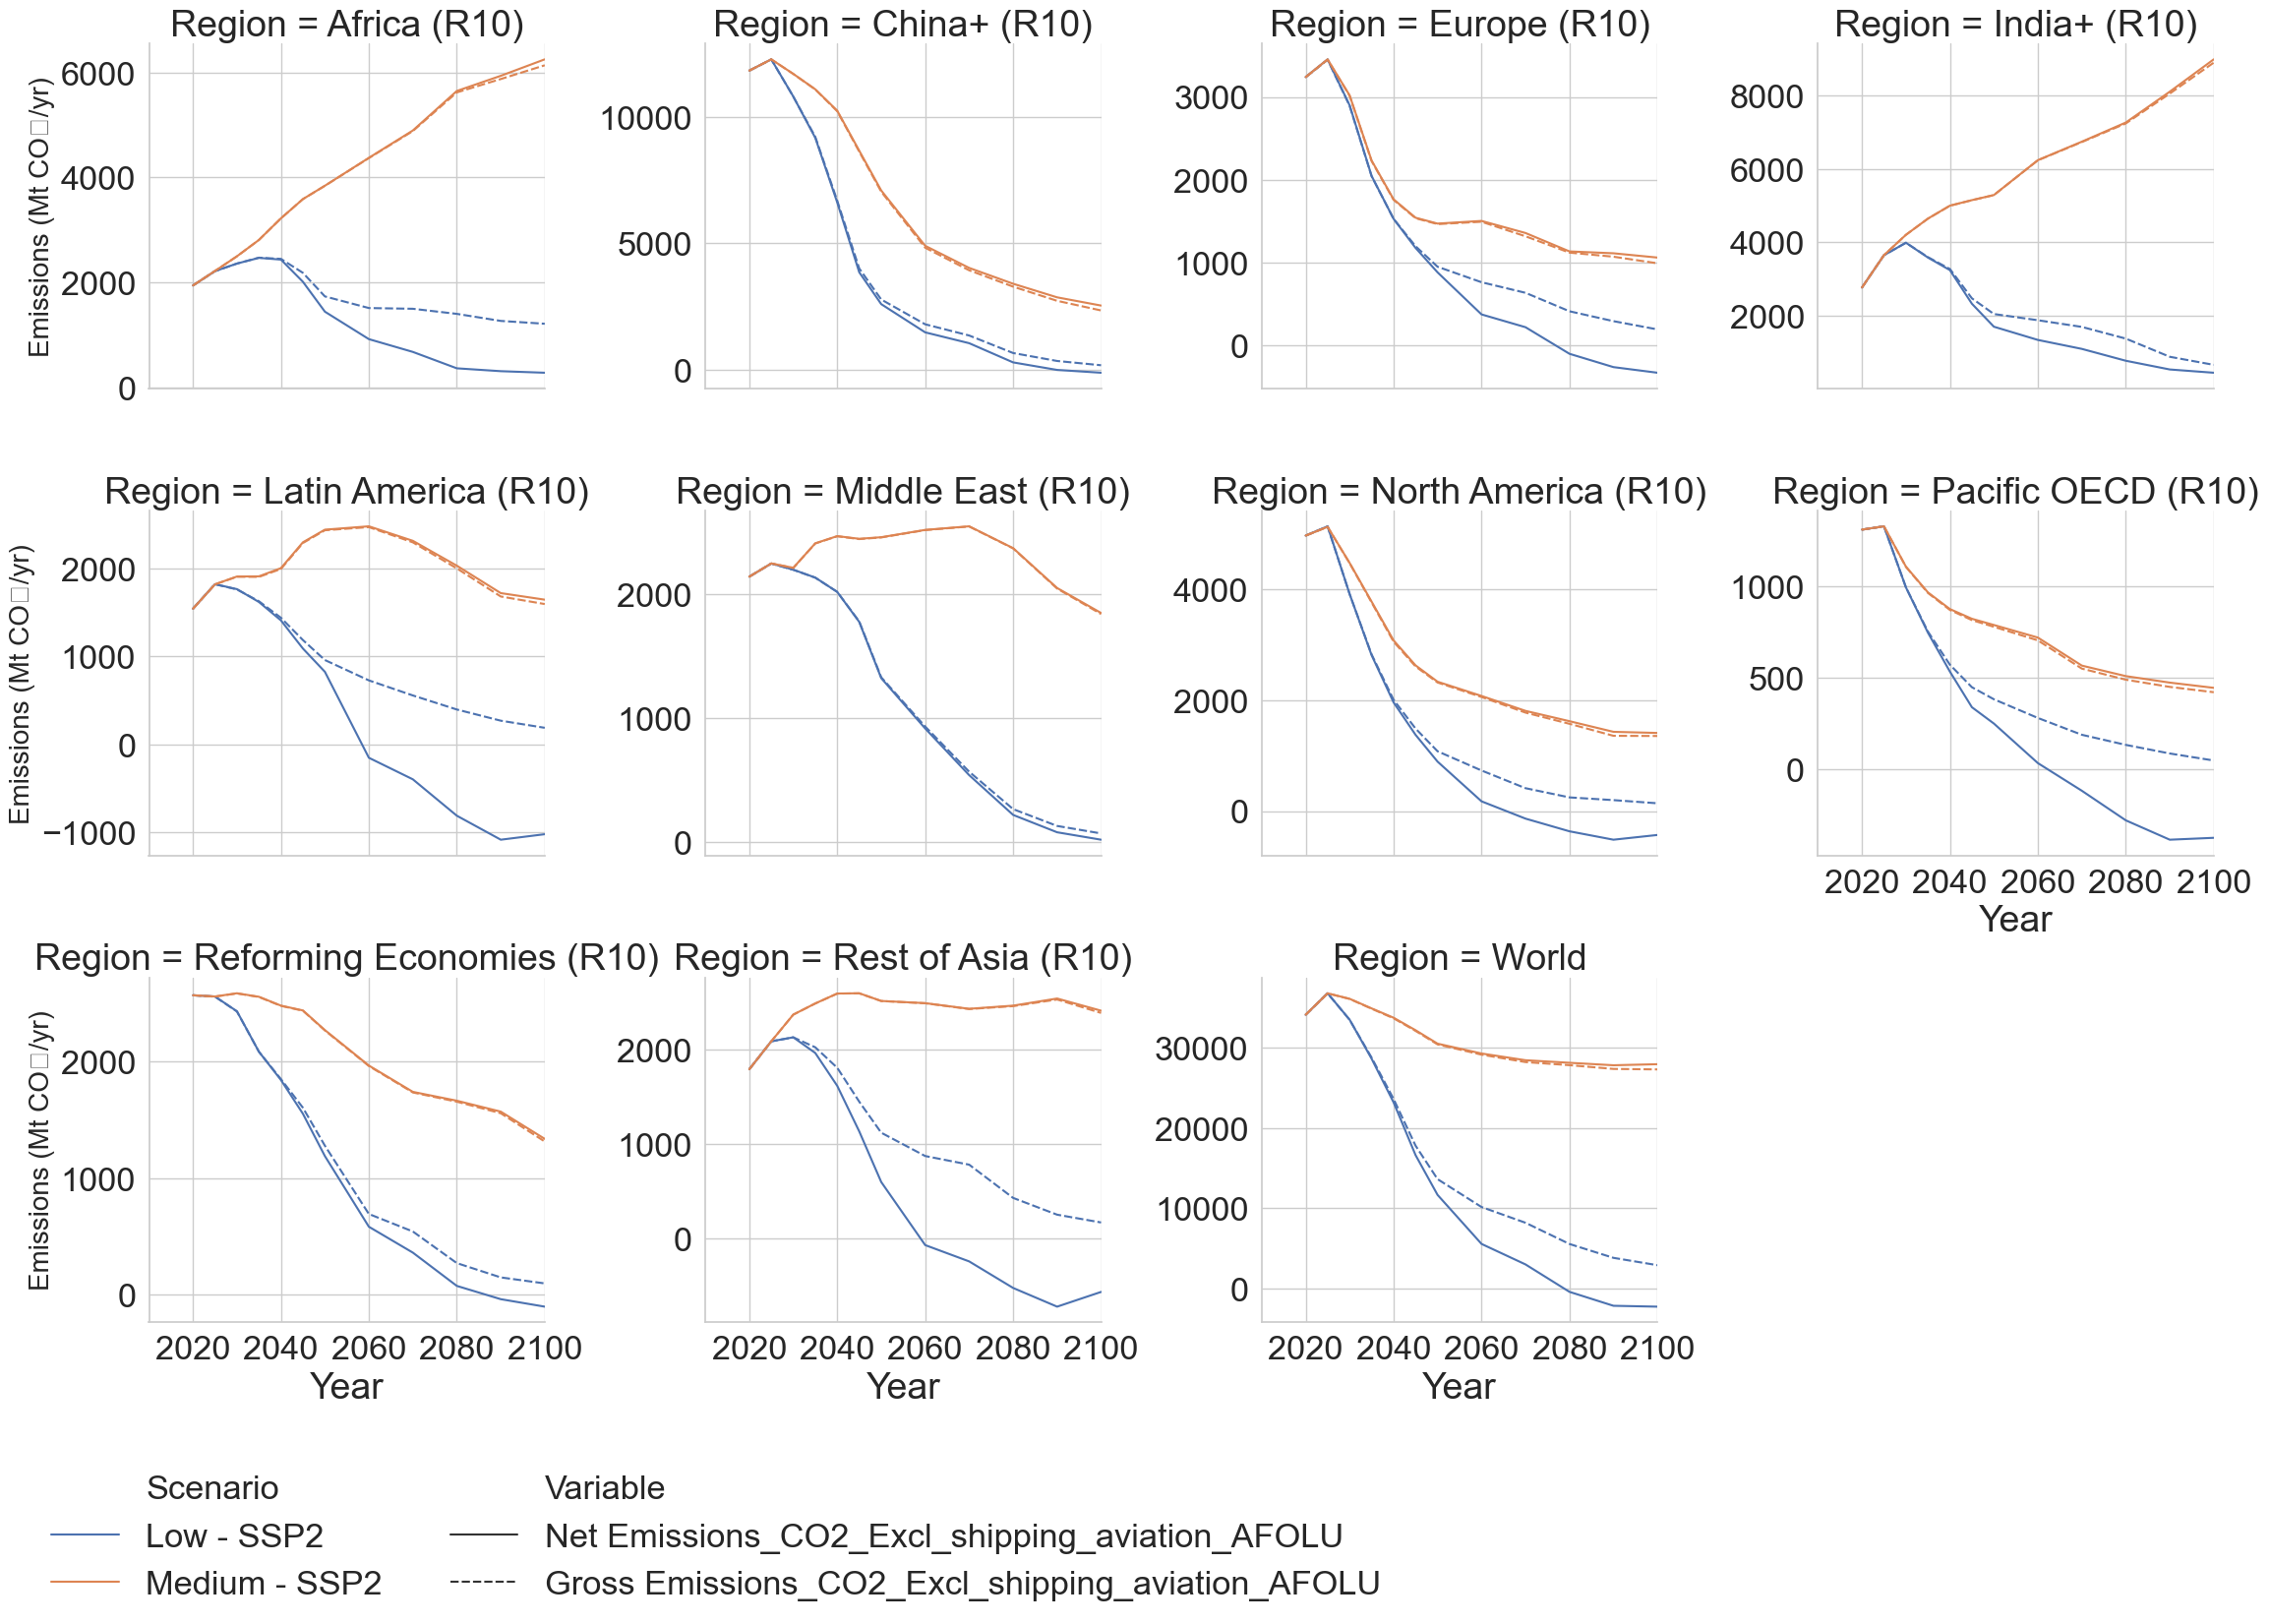

In [56]:
sns.set_theme(style="whitegrid", font_scale=2.25)
g = sns.relplot(data=df_IMAGE_CO2_total, x="Year", y="Value", hue="Scenario", style="Variable", kind="line", col="Region", col_wrap=4,
                aspect=1.2, facet_kws={"sharey": False, "sharex": True})
g.set_ylabels("Emissions (Mt CO₂/yr)", fontsize=20)
g.set(xticks=range(2020, 2101, 20), xlim=(2010, 2100))
sns.move_legend(g, "upper center", bbox_to_anchor=(0.25, 0),  ncol=2,  title=None, frameon=False)